#### Interpretabilidad del modelo XGBoost con shap

Como vimos en el notebook 07 XGBoost fue el modelo que obtuvo un mejor rendimiento. Por la naturaleza del modelo XGBoost se convierte en una "caja negra" que solo conocemos las entradas y la salidas, pero no conocemos el ¿por qué? Justamente Shap responde qué variables impulsan las predicciones a manera global e individual.

In [5]:
#impprtación de librerías
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.data.load_split import load_raw_data,split_data
from src.models.train_model import (build_logistic_pipeline,build_random_forest_pipeline,build_xgboost_pipeline)
from src.models.evaluation import evaluate_model_cv, evaluate_on_test

In [2]:
#entrenar el pipeline del XGBoost
df = load_raw_data()
X_train, X_test, y_train, y_test = split_data(df)
pipe = build_xgboost_pipeline()
pipe.fit(X_train,y_train)
print ("-------------XGBoost entrenado-------------")

-------------XGBoost entrenado-------------


In [6]:
#shap necesita los datos procesados, tal como los recibe el modelo. Vamos a calcular los valores shap sobre una muestra del test de 3000 registros 
# para que sea rápidp
import shap

preprocessor = pipe.named_steps["preprocessor"]
model = pipe.named_steps["model"]

X_sample = X_test.sample(n=3000, random_state=42)
X_sample_prep = pd.DataFrame(
    preprocessor.transform(X_sample),
    columns=X_test.columns,
    index=X_sample.index,
)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample_prep)
print("------------Valores shap calculados:",shap_values.shape)

------------Valores shap calculados: (3000, 10)


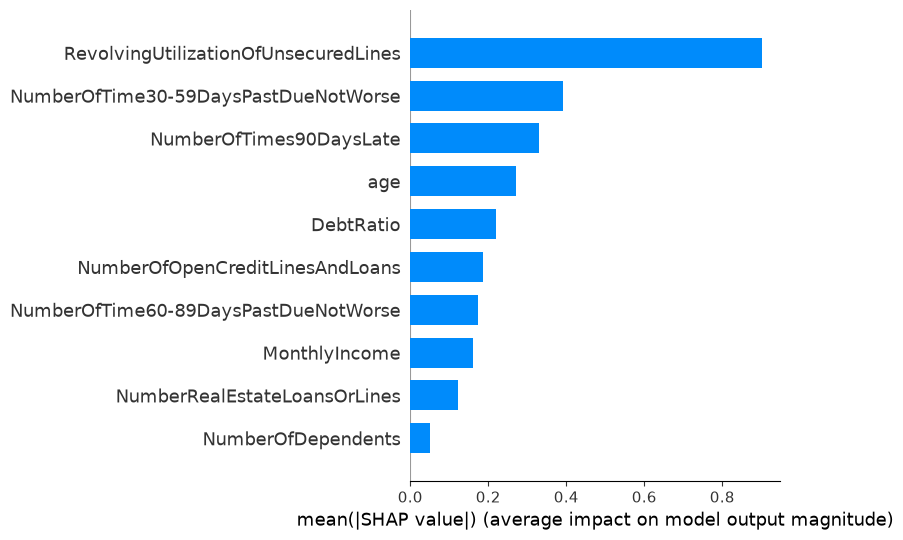

In [ ]:
#importancia global de las variables
#Las barras miden el impacto promedio en valor absoluto de cada variable sobre las predicciones
shap.summary_plot(shap_values, X_sample_prep, plot_type="bar", show=True)

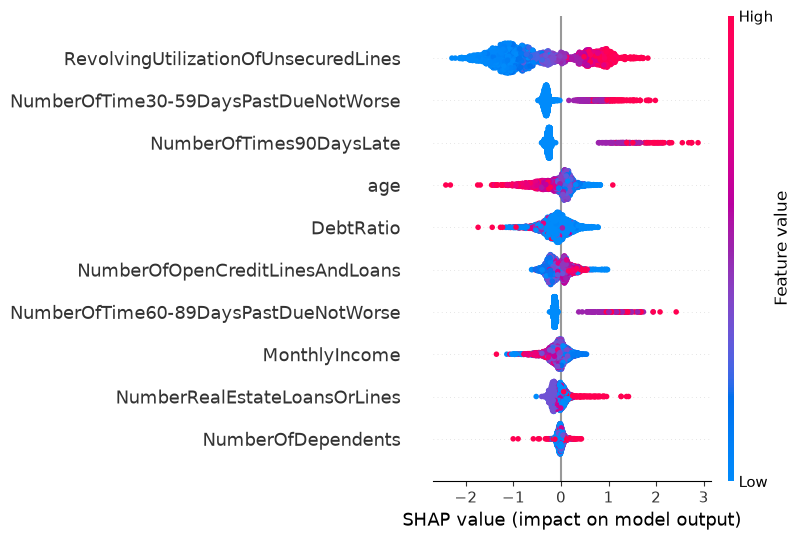

In [ ]:
#beeswarm: cómo afecta cada variable
#este gráfico muestra para cada variable si los valores altos(rojo) o bajos(azul)
#empujan la predicción hacia un mayor o menor riesgo
shap.summary_plot(shap_values, X_sample_prep,show=True)

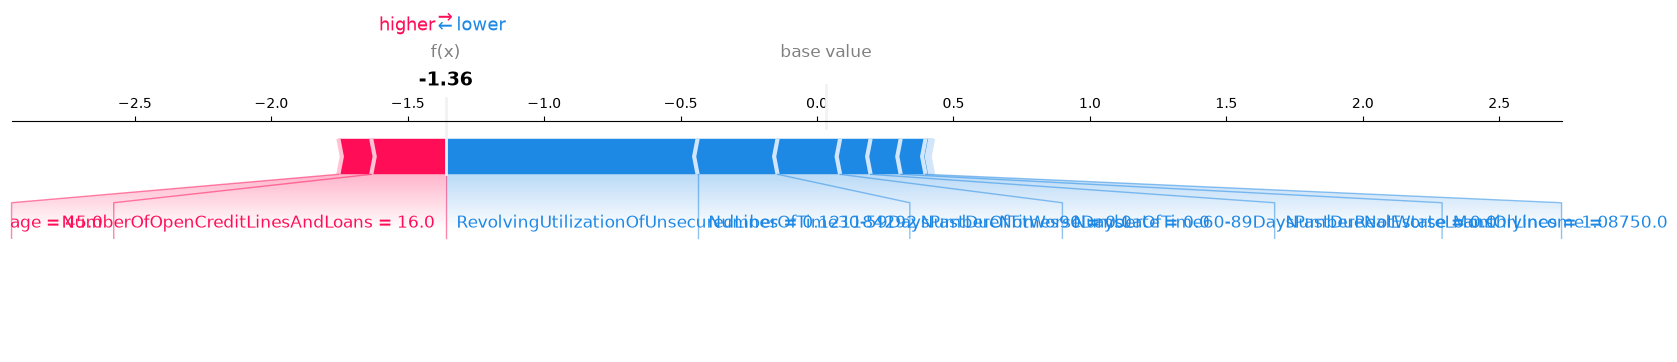

In [ ]:
#explicación de un cliente individual
#shap puede explicar de manera individual que variables empujaron el riesgo de un cliente.
#Permite justificar una decisión de crédito ante un cliente o ente regulador.
idx= 0
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_sample_prep.iloc[idx],
    matplotlib=True,
    show=True,
)

##### Conclusiones obtenidas

1. **Importancia global de las variables** RevolvingUtilizationOfUnsecuredLines(0.9) es por lejos la variable más fuerte en la predicción, seguida de NumberOfTime30-59DaysPastDueNotWorse(0.4) y NumberOfTimes90DaysLate(0.3)
2. **Cómo afecta cada variable** Alta utilización de crédito y más atrasos previos mayor riesgo de mora.  Mayor edad y mayor ingresos mensuales menor riesgo de mora.
3. **Explicación individual** Para este cliente, el modelo lo clasifica como un cliente con baja probabilidad de mora. Las características que reducen el riesgo tienen mayor peso que las que lo aumentan.